In [2]:
import sys  
sys.path.insert(1, '~/autodriving/self-training-segmentation')

from dataset.ugm import UGMDataset, UGMDataModule
from utils import colorize_segmentation, normalize_entropy
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from skimage import filters
from skimage.measure import label

/home/esr/miniconda3/envs/autodriving/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ugm_dataset = UGMDataset(
    '/media/esr/ssd0/dataset/2025-01-10/', 
    size=(256, 256), 
    return_teacher_logits=True, 
    use_refinement=True, 
    entropy_threshold=1.0,
    use_transform=False,
)

for i in range(len(ugm_dataset)):
    image, t_logits, refined_label = ugm_dataset[i]
    print(f"Image shape: {image.shape}, Teacher logits shape: {t_logits.shape if t_logits is not None else 'N/A'}, Refined label shape: {refined_label.shape if refined_label is not None else 'N/A'}")
    break

Image shape: torch.Size([3, 256, 256]), Teacher logits shape: torch.Size([19, 256, 256]), Refined label shape: torch.Size([256, 256])


## Show comparison before after refinement

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

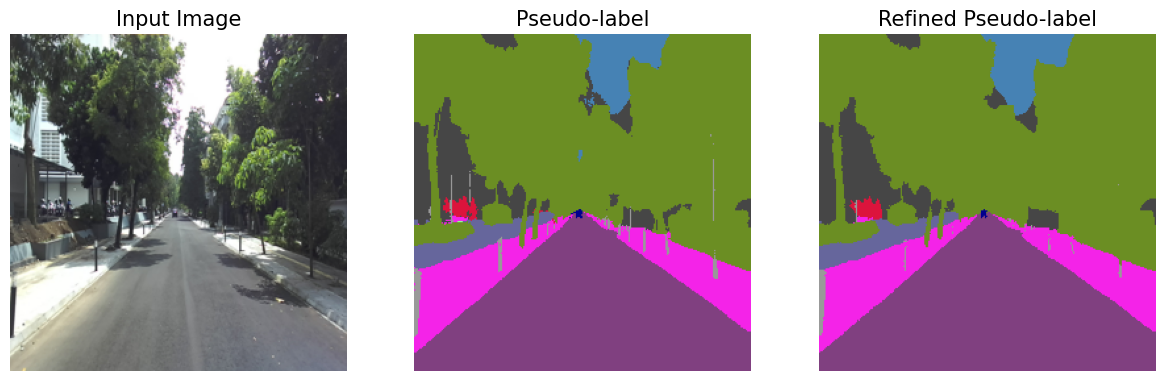

In [266]:
idx = 123
# idx = 2510
# idx = 4530
# idx = 2660
image, t_logits, refined_label = ugm_dataset[idx]

image_np = image.numpy().transpose(1, 2, 0)
t_probs = torch.softmax(t_logits, dim=0)
t_label = t_probs.argmax(dim=0)

t_label_np = t_label.numpy()
refined_label_np = refined_label.numpy()

# Visualize the results
plt.figure(figsize=(20, 5))
plt.subplot(1, 4, 1)
plt.imshow(image_np)
plt.title('Input Image', fontsize=15)
plt.axis('off')
plt.subplot(1, 4, 2)
plt.imshow(colorize_segmentation(t_label_np).permute(1, 2, 0))
plt.title('Pseudo-label', fontsize=15)
plt.axis('off')
plt.subplot(1, 4, 3)
plt.imshow(colorize_segmentation(refined_label_np).permute(1, 2, 0))
plt.title('Refined Pseudo-label', fontsize=15)
plt.axis('off')
# plt.subplot(1, 4, 4)
# plt.imshow(colorize_segmentation(pred).permute(1, 2, 0))
# plt.title('Model Prediction Segmentation')
# plt.axis('off')
# plt.tight_layout()
# plt.show()

## Show input image

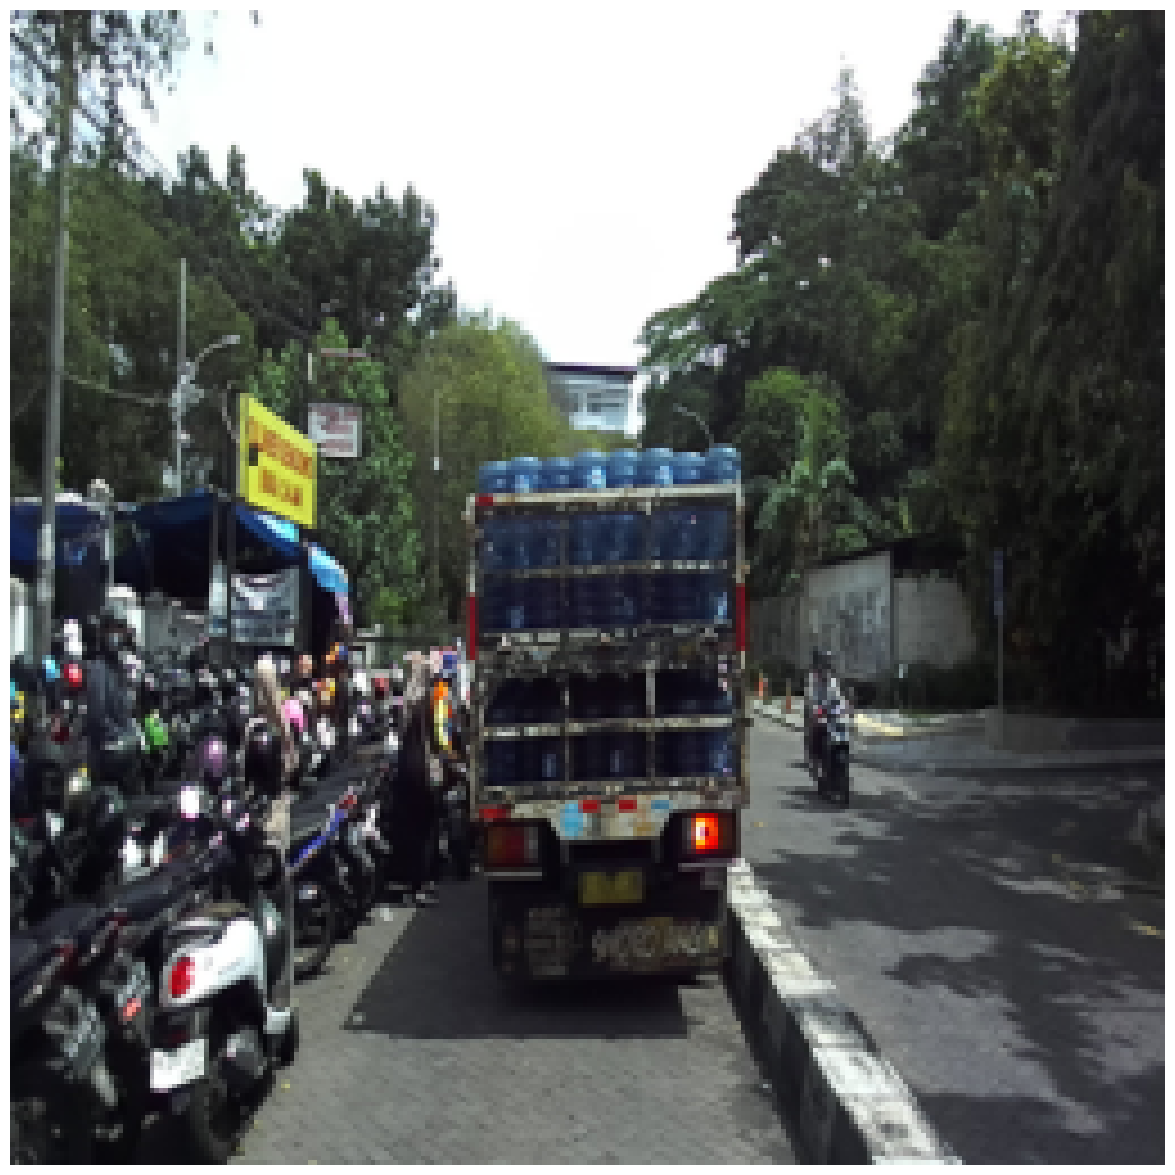

In [8]:
plt.figure(figsize=(15, 15))
plt.imshow(image_np)
plt.axis('off')
plt.show()

## Show Refined Pseudo-label

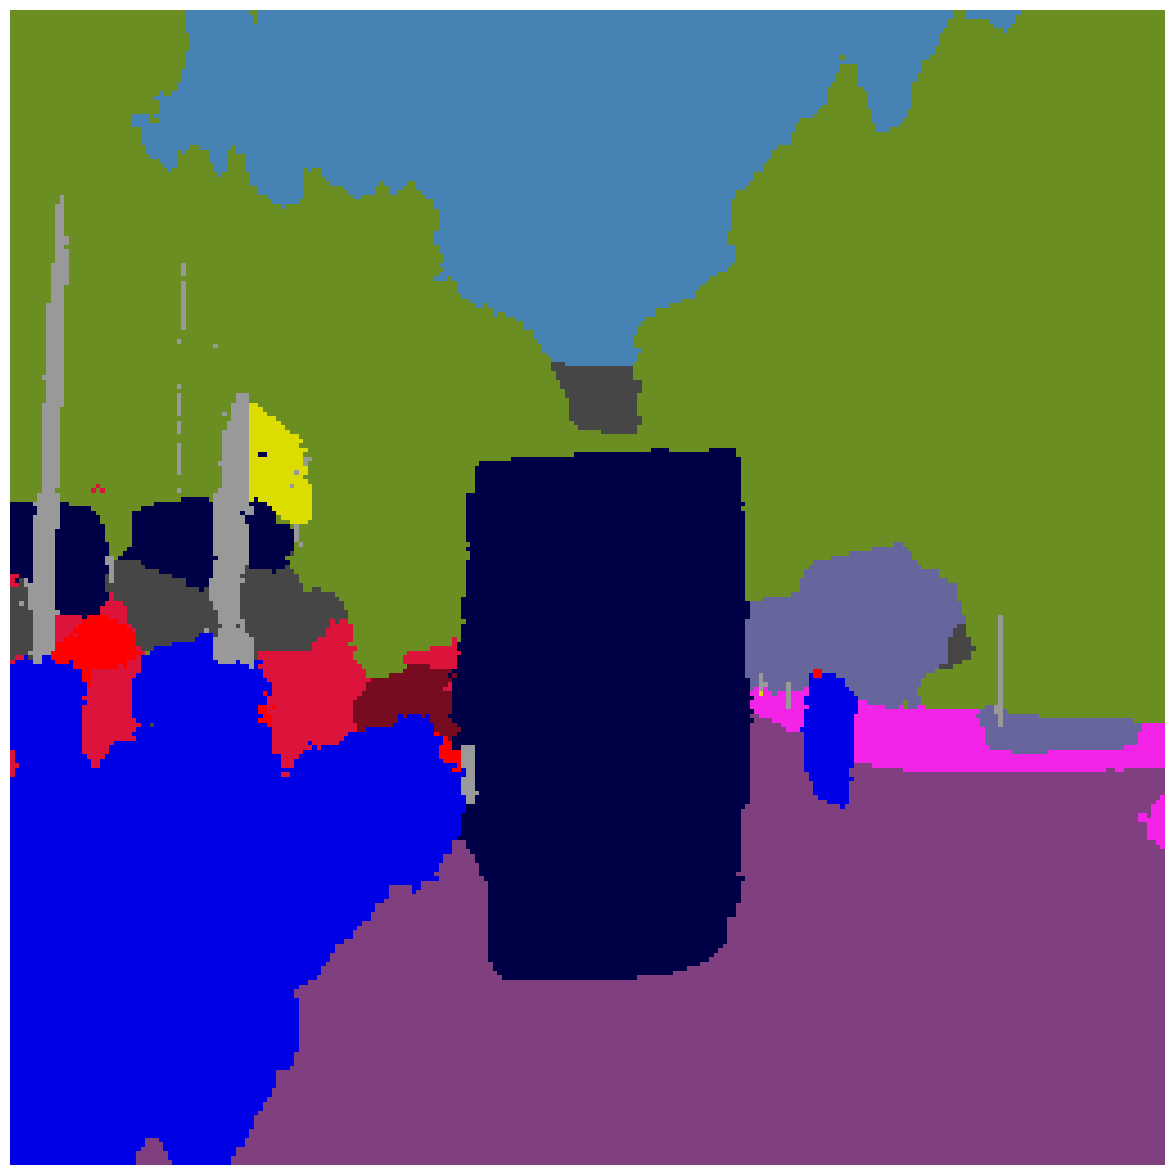

In [14]:
plt.figure(figsize=(15, 15))
plt.imshow(colorize_segmentation(refined_label_np).permute(1, 2, 0))
plt.axis('off')
plt.show()

## Show Prediction

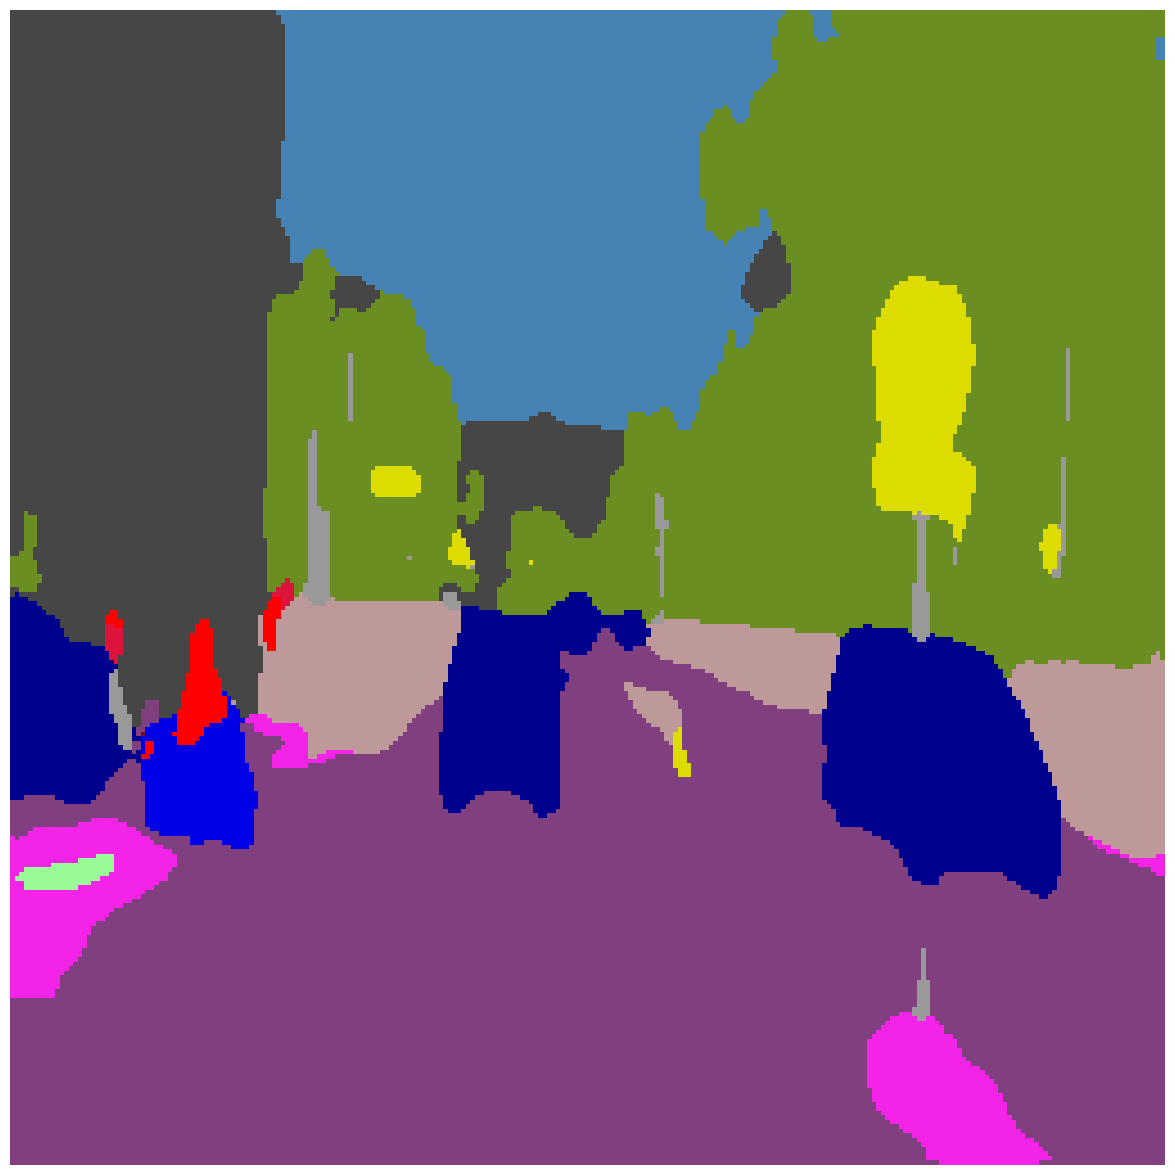

In [66]:
from train import BaseModel

dm = UGMDataModule(
    '/media/esr/ssd0/dataset/2025-01-10/',
    batch_size=1,
    num_workers=4,
    size=(256, 256),
    return_teacher_logits=True,
    use_refinement=True,
    entropy_threshold=1.0,
)
dm.setup()
predict_loader = dm.predict_dataloader()

# Load the model
root_path = '/media/esr/ssd0'
model_path = 'timm-efficientnet-b0_unet/refinement_thr-0.45_imagenet_dropout-0.5_lr-0.001_kd_T2.0_w-0.001_256x256'
model = BaseModel.load_from_checkpoint(
    f'{root_path}/saved_models/{model_path}/best.ckpt',
    hparams_file=f'{root_path}/saved_models/{model_path}/hparams.yaml'
    )
model.eval()
with torch.no_grad():
    images, t_logits, refined_labels = predict_loader.dataset[idx]
    outputs = model(images.cuda().unsqueeze(0))
    pred = outputs.argmax(dim=1).squeeze(0).cpu().numpy()
    
    t_probs = F.softmax(t_logits, dim=0)
    entropy = normalize_entropy(t_probs)
    mask = entropy < 0
    
    masked_entropy = entropy * ~mask

plt.figure(figsize=(15, 15))
plt.imshow(colorize_segmentation(pred).permute(1, 2, 0))
plt.axis('off')
plt.show()

## Show Entropy Mask

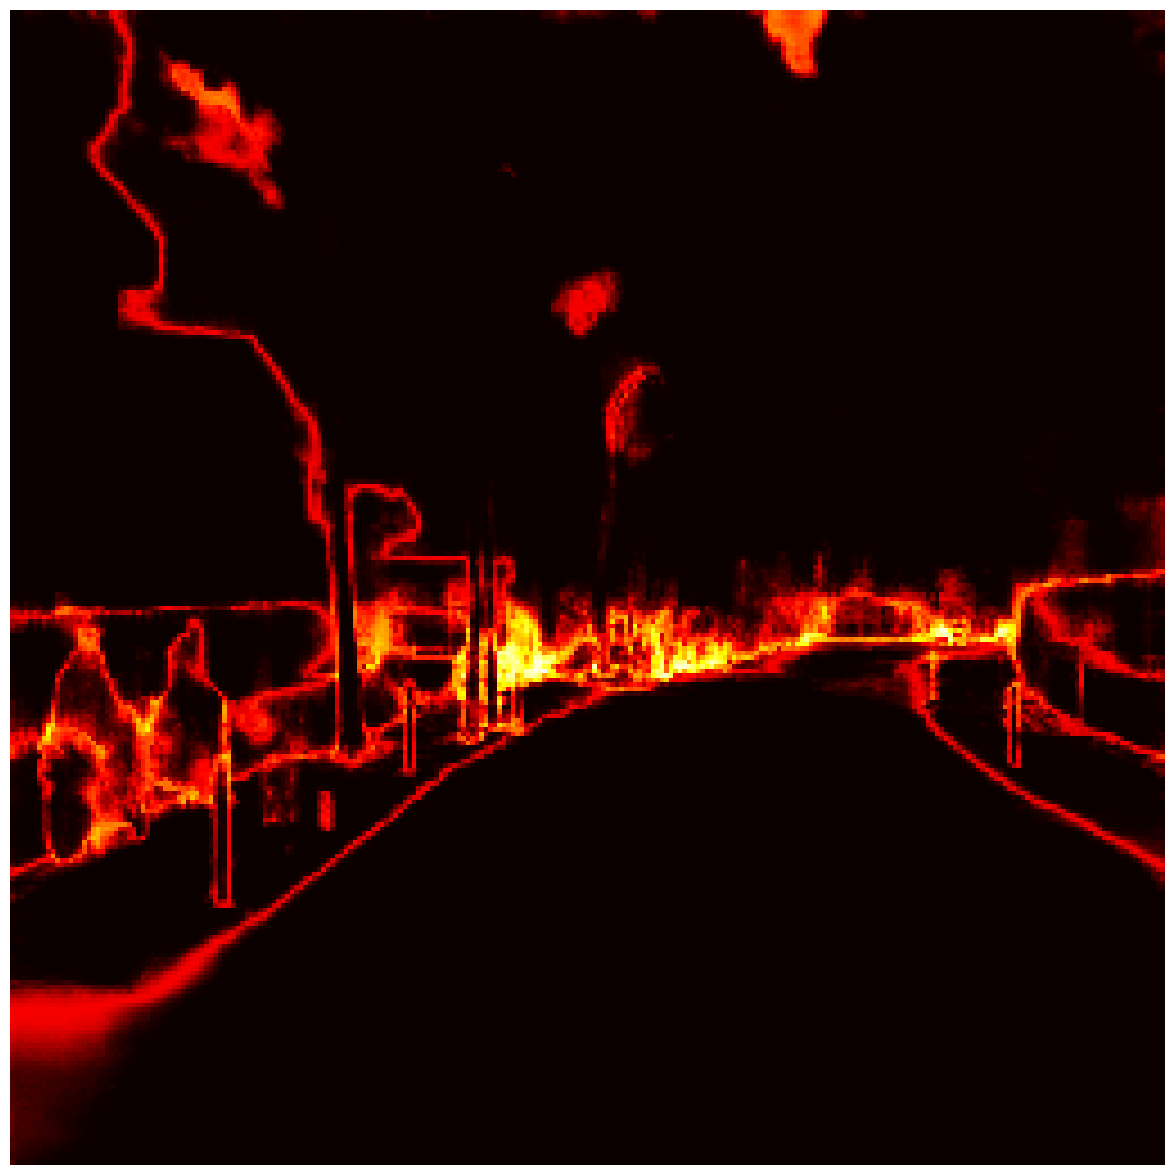

In [22]:
plt.figure(figsize=(15, 15))
plt.imshow(masked_entropy.cpu().numpy(), cmap='hot')
plt.axis('off')
plt.show()

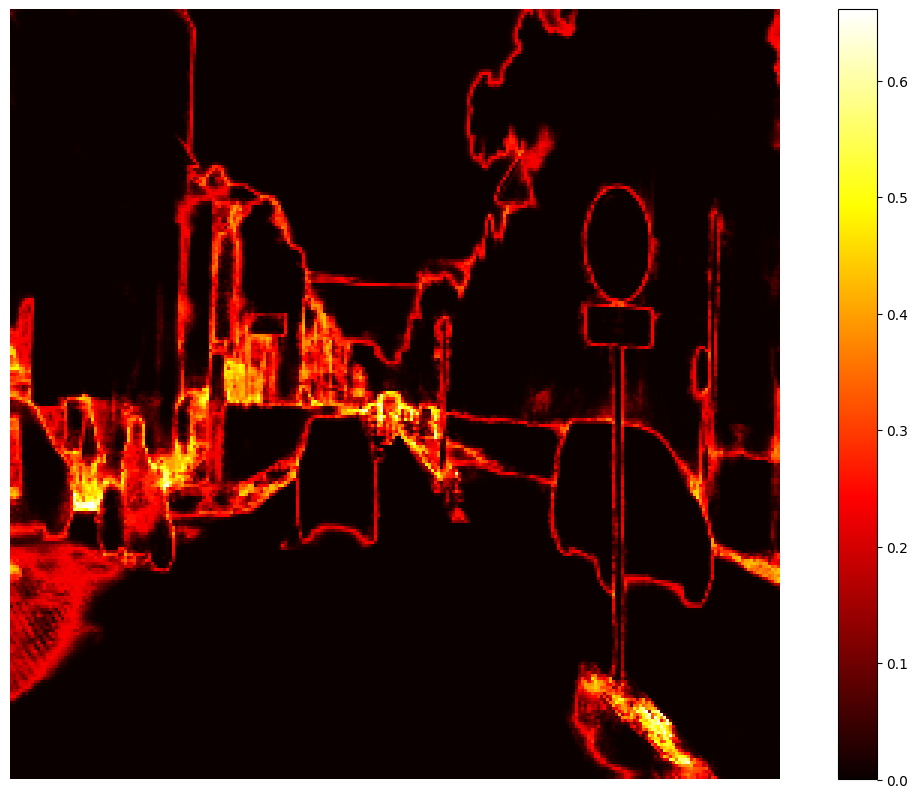

In [67]:
fig, ax = plt.subplots(figsize=(15,10))
im = ax.imshow(entropy.cpu().numpy(), cmap='hot')
cbar = fig.colorbar(im, ax=ax)
plt.axis('off')
plt.show()

## taging

In [104]:
import cv2
import matplotlib.pyplot as plt

def zoom_image(image, pos=[[10, 10, 10, 10]]):
    for p in pos:
        x, y, w, h = p
        cv2.rectangle(image, (x, y), (x+w, y+h), (255, 255, 255), 2)
        # roi = image[y:y+h, x:x+w]
        # zoom_factor = 2
        # roi_zoomed = cv2.resize(roi, None, fx=zoom_factor, fy=zoom_factor, interpolation=cv2.INTER_LINEAR)
    
        # plt.figure(figsize=(10,10))
        # plt.imshow(roi_zoomed)
        # plt.axis('off')
        # plt.show()
        
    plt.figure(figsize=(10,10))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

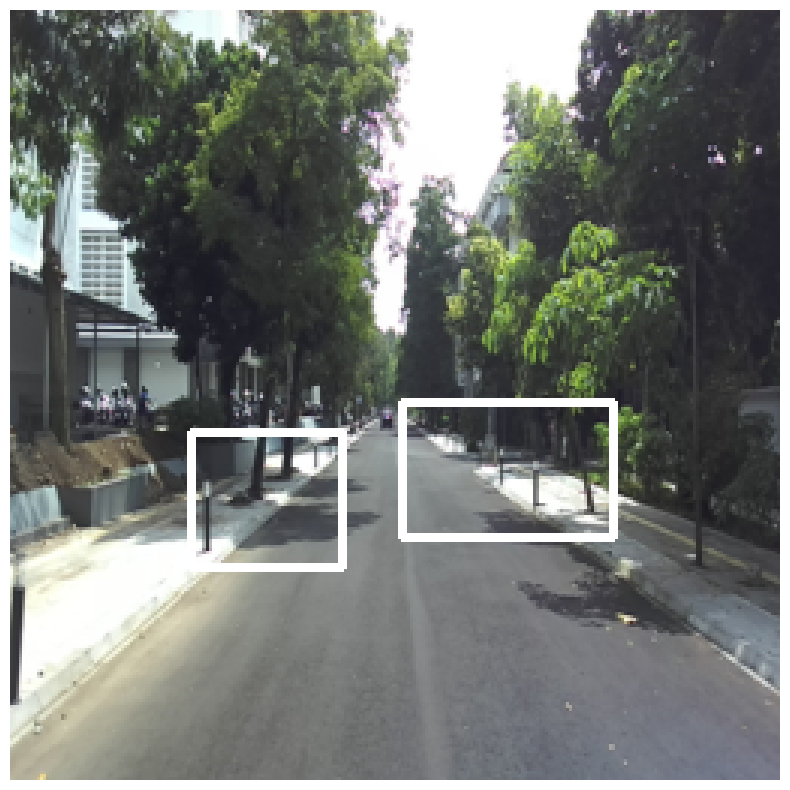

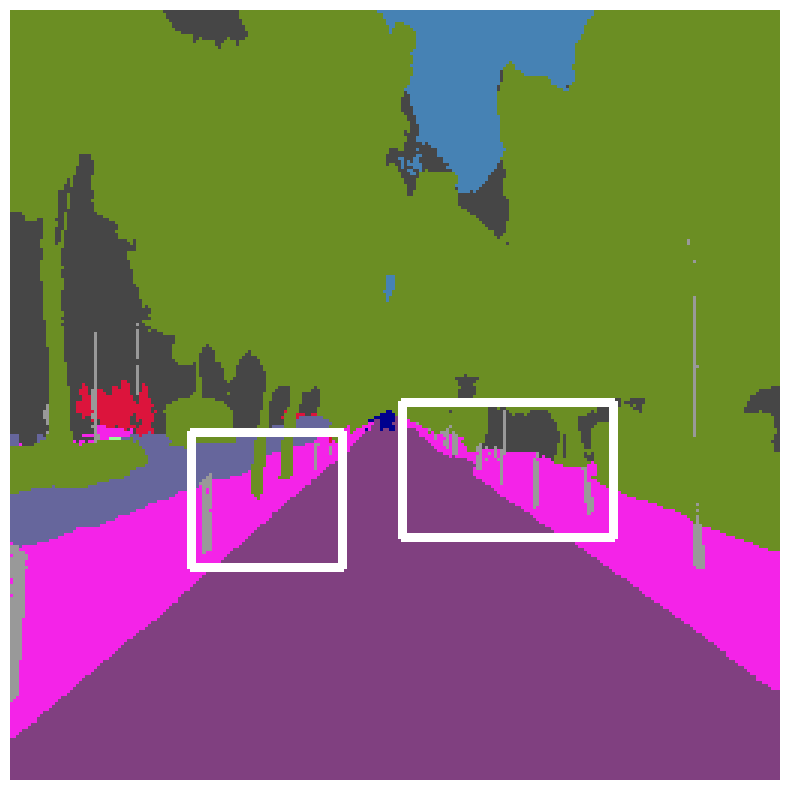

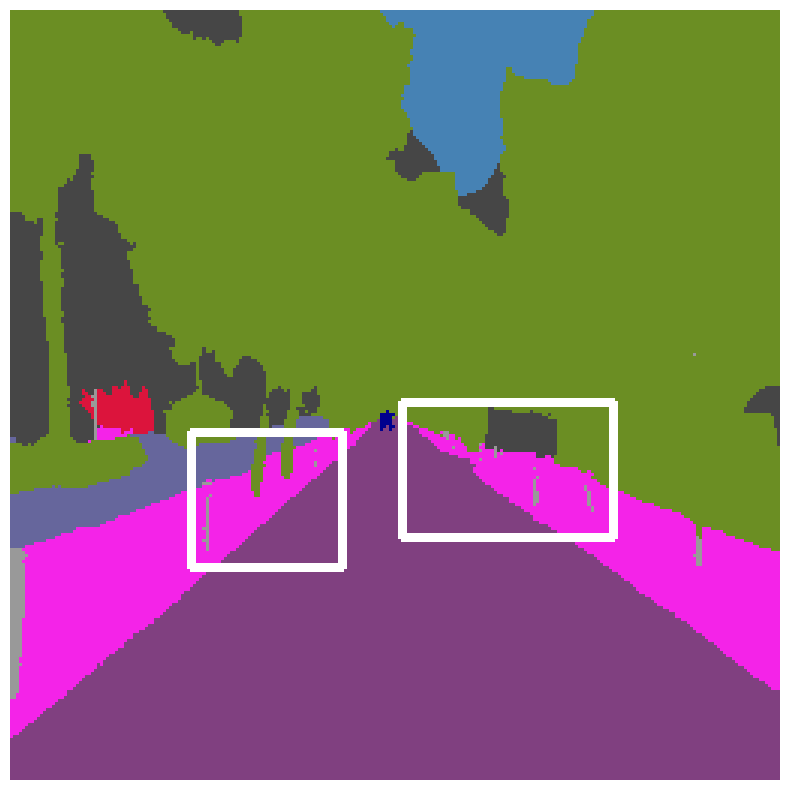

In [279]:
image = image_np.copy()
col_pl = colorize_segmentation(t_label_np).permute(1, 2, 0).numpy()
col_refined_pl = colorize_segmentation(refined_label_np).permute(1, 2, 0).numpy()
pos = [
    [130, 130, 70, 45],
    [60, 140, 50, 45]
    
    # [155, 95, 20, 25],
    # [65, 105, 20, 50]
    
    # [45, 75, 75, 60],
    # [0, 75, 120, 130],
    # [180, 170, 75, 80],
    
    # [45, 75, 75, 60],
    # [0, 120, 45, 60],
    # [215, 190, 40, 40],
]
zoom_image(image, pos)
zoom_image(col_pl, pos)
zoom_image(col_refined_pl, pos)

# Quantifying Pseudo-Label Quality Changes

In [5]:
def calculate_consistency_metrics(teacher_labels, refined_labels):
    """
    Quantifies changes between teacher and refined pseudo-labels.
    Args:
        teacher_labels (np.ndarray): Array of teacher labels.
        refined_labels (np.ndarray): Array of refined labels.
    Returns:
        dict: Consistency metrics.
    """
    # Pixel-wise agreement
    pixel_agreement = np.mean(teacher_labels == refined_labels)

    # Class distribution shift (KL divergence)
    num_classes = max(teacher_labels.max(), refined_labels.max()) + 1
    orig_counts = np.bincount(teacher_labels.flatten(), minlength=num_classes)
    refined_counts = np.bincount(refined_labels.flatten(), minlength=num_classes)

    # Normalize to probability distributions
    orig_dist = orig_counts / np.sum(orig_counts)
    refined_dist = refined_counts / np.sum(refined_counts)

    # KL divergence (teacher || refined), safe for zeros
    mask = (orig_dist > 0) & (refined_dist > 0)
    distribution_kl = np.sum(orig_dist[mask] * np.log2(orig_dist[mask] / refined_dist[mask]))

    # Boundary fidelity (using edge detection)
    teacher_edges = filters.sobel(teacher_labels)
    refined_edges = filters.sobel(refined_labels)
    # Both nonzero indicates edge, agreement where both edge/no-edge match
    edge_agreement = np.mean((teacher_edges > 0) == (refined_edges > 0))

    return {
        'pixel_agreement': pixel_agreement,
        'distribution_kl': distribution_kl,
        'edge_agreement': edge_agreement
    }

    
metrics = calculate_consistency_metrics(t_label_np, refined_label_np)
print("Consistency Metrics:", metrics)

Consistency Metrics: {'pixel_agreement': np.float64(0.9727630615234375), 'distribution_kl': np.float64(0.002197291114641669), 'edge_agreement': np.float64(0.95257568359375)}


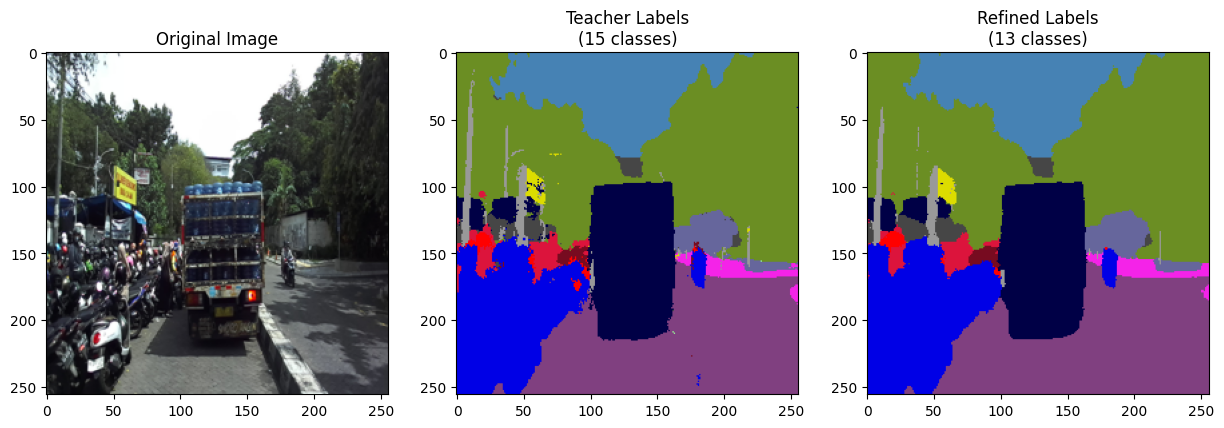

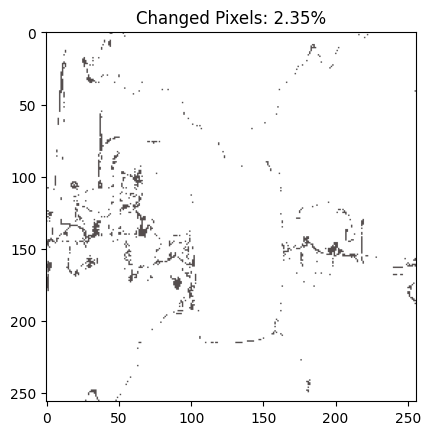

In [15]:
def visualize_changes(image, teacher_label, refined_label):
    colorized_label = colorize_segmentation(t_label).permute(1, 2, 0).numpy()
    colorized_refined_label = colorize_segmentation(refined_label).permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, 3, figsize=(15,5))
    ax[0].imshow(image)
    ax[0].set_title('Original Image')
    ax[1].imshow(colorized_label)
    ax[1].set_title(f'Teacher Labels\n({np.unique(teacher_label).size} classes)')
    ax[2].imshow(colorized_refined_label)
    ax[2].set_title(f'Refined Labels\n({np.unique(refined_label).size} classes)')
    
    # Highlight differences
    diff_mask = teacher_label != refined_label
    plt.figure()
    plt.imshow(np.ma.masked_where(~diff_mask, diff_mask), cmap='hot', alpha=0.7)
    plt.title(f'Changed Pixels: {np.mean(diff_mask)*100:.2f}%')
    plt.show()
    
visualize_changes(image_np, t_label_np, refined_label_np)

# Entropy Threshold Impact Analysis

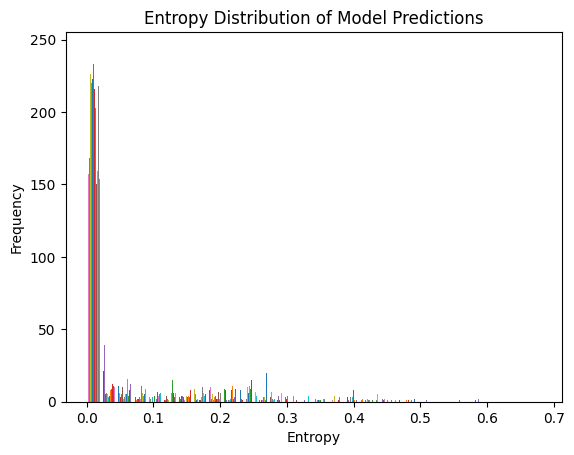

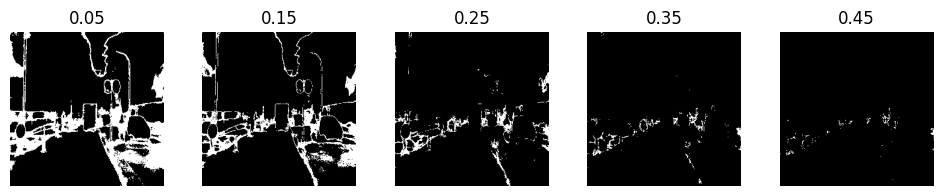

In [7]:
from utils import normalize_entropy

def analyze_entropy_impact(teacher_prob_maps, thresholds=[0.05, 0.15, 0.25, 0.35, 0.45]):
    pixel_entropy = normalize_entropy(teacher_prob_maps)
    
    plt.hist(pixel_entropy, bins=30)
    plt.xlabel('Entropy')
    plt.ylabel('Frequency')
    plt.title('Entropy Distribution of Model Predictions')
    plt.show()
    
    plt.figure(figsize=(12, 2))
    for i, thresh in enumerate(thresholds, 1):
        mask = pixel_entropy > thresh
        plt.subplot(1, len(thresholds), i)
        plt.imshow(mask, cmap='gray')  # Adjust shape as appropriate
        plt.title(f'{thresh}')
        plt.axis('off')
    plt.show()
    
analyze_entropy_impact(t_probs)

# Diagnosing Adaptive Threshold Failure

In [8]:
def diagnose_adaptive_threshold(
    adaptive_mask, 
    teacher_probs, 
    student_preds, 
    teacher_labels, 
    adaptive_thresholds
):
    """
    Identifies failure modes of adaptive thresholding.

    Parameters:
        adaptive_mask: np.ndarray
            Binary or soft mask after thresholding.
        teacher_probs: np.ndarray
            Probabilities output by teacher model (H, W, num_classes).
        student_preds: np.ndarray
            Student predictions (H, W), int.
        teacher_labels: np.ndarray
            Teacher pseudo-labels (H, W), int.
        adaptive_thresholds: list or np.ndarray
            List/array of per-image thresholds.

    Returns:
        dict with calibration gap, class errors, and mean low-confidence region size.
    """
    # 1. Threshold variability analysis
    threshold_variation = np.std(adaptive_thresholds)
    print(f"Threshold variability (σ): {threshold_variation:.4f}")
    
    # 2. Confidence-accuracy mismatch
    bin_accuracies = []
    bin_confidences = []
    for conf_level in np.linspace(0, 1, 11):
        mask = (teacher_probs.max(axis=-1) > conf_level)
        if np.any(mask):
            bin_accuracies.append(np.mean(student_preds[mask] == teacher_labels[mask]))
            bin_confidences.append(np.mean(teacher_probs.max(axis=-1)[mask]))
        else:
            bin_accuracies.append(np.nan)
            bin_confidences.append(np.nan)
    
    # 3. Class-specific failure
    class_errors = {}
    n_classes = teacher_probs.shape[-1]
    for class_id in range(n_classes):
        class_mask = teacher_labels == class_id
        if np.any(class_mask):
            class_acc = np.mean(student_preds[class_mask] == teacher_labels[class_mask])
            class_errors[class_id] = 1 - class_acc
        else:
            class_errors[class_id] = np.nan
    
    # 4. Spatial analysis
    low_conf_regions = label(adaptive_mask < 0.5)
    # Ignore background (label 0)
    unique_labels = np.unique(low_conf_regions)
    region_sizes = [np.sum(low_conf_regions == i) for i in unique_labels if i != 0]
    mean_region_size = np.mean(region_sizes) if region_sizes else 0
    
    # Compute calibration gap, ignoring nan
    cal_gaps = np.abs(np.array(bin_accuracies) - np.array(bin_confidences))
    calibration_gap = np.nanmean(cal_gaps)
    
    return {
        'calibration_gap': calibration_gap,
        'class_errors': class_errors,
        'mean_lowconf_region_size': mean_region_size
    }


In [9]:
act_dataset = UGMDataset(
    '/media/esr/ssd0/dataset/2025-01-10/', 
    size=(256, 256), 
    return_teacher_logits=True, 
    use_refinement=True, 
    entropy_threshold='act',
    use_transform=False,
)

_, _, act_labels = act_dataset[idx]

# change all class to zero except ignore class
for c in range(19):
    if c != 0:
        act_labels[act_labels == c] = 0
act_mask = act_labels.numpy()
my_thresholds = [0.05, 0.15, 0.25, 0.35, 0.45]


result = diagnose_adaptive_threshold(
    adaptive_mask=act_mask,
    teacher_probs=t_probs,
    student_preds=s_pred,
    teacher_labels=t_label,
    adaptive_thresholds=my_thresholds
)
print(result)


NameError: name 's_pred' is not defined

# Cityscapes

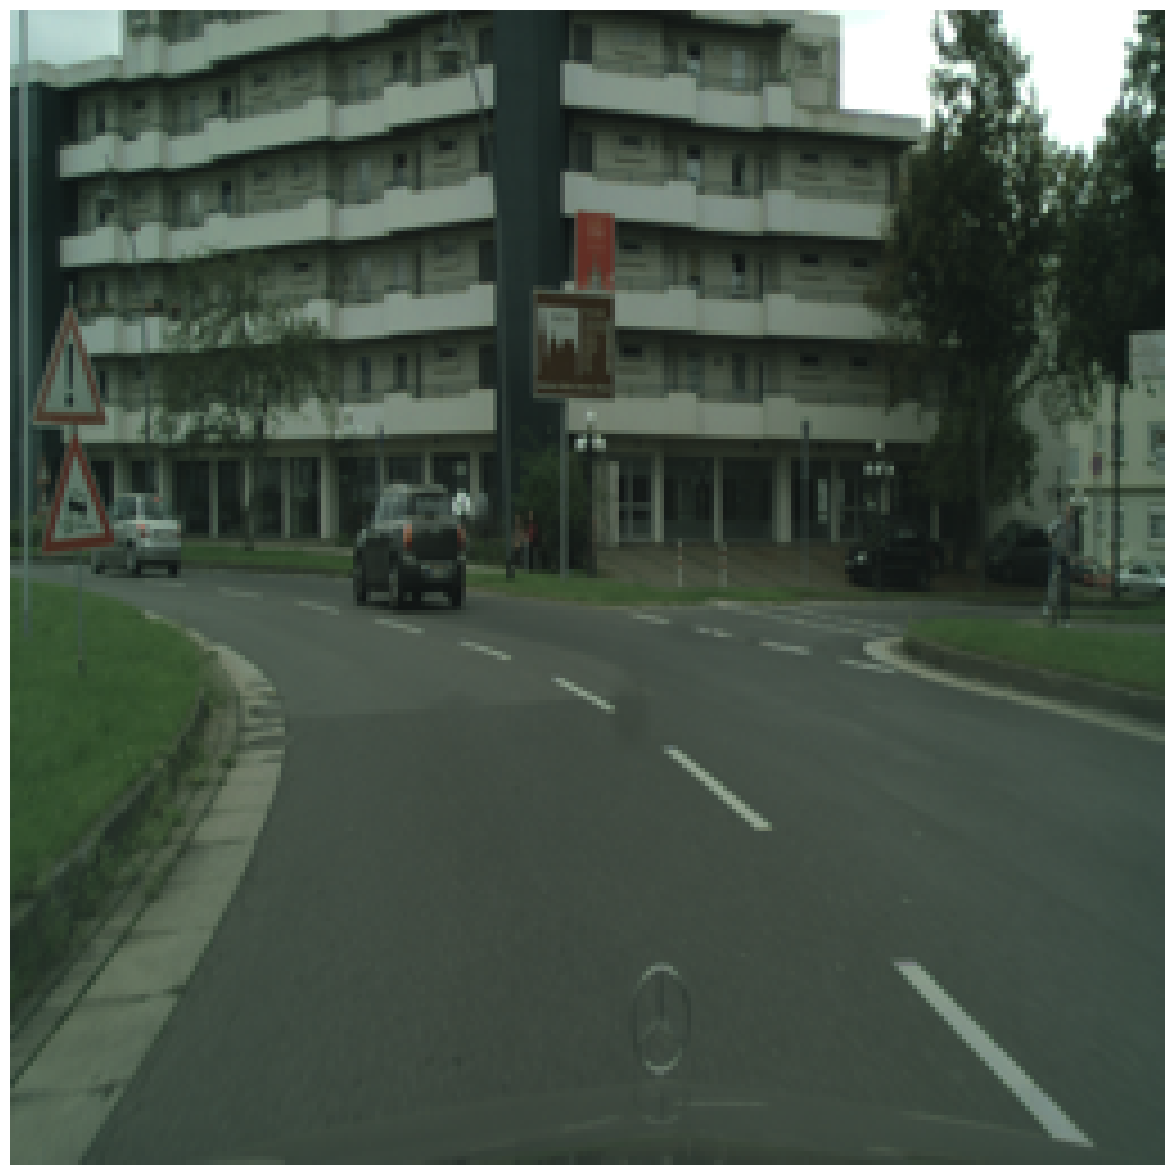

In [3]:
# load cityscapes dataset
from dataset.cityscapes import CityscapeDataset

cityscapes_path = '/media/esr/ssd0/cityscapes/'
cityscapes_dataset = CityscapeDataset(
    cityscapes_path, 
    size=(256, 256),
)
for i in range(len(cityscapes_dataset)):
    image, label = cityscapes_dataset[i]
    break

plt.figure(figsize=(15, 15))
plt.imshow(image)
plt.axis('off')
plt.show()